In [41]:
import os, math, glob, time, json
from pathlib import Path
from typing import List, Tuple
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
import numpy as np
from PIL import Image

In [42]:
import os

data_path = r"R:\DeepfakeTIMIT"
print("Folders inside:", os.listdir(data_path))


Folders inside: ['.dircksum', 'Dataset', 'deepfake_images_1.png', 'deepfake_images_2.png', 'faces', 'fadg0-fram1-roi93.mov', 'fadg0-original.mov', 'fram1-original.mov', 'higher_quality', 'lower_quality', 'manifests', 'README.txt', 'Test', 'Train', 'Validation']


In [43]:
import os, re, glob, pandas as pd
from pathlib import Path

BASE = r"R:\DeepfakeTIMIT"     # your dataset root
print("Top-level:", os.listdir(BASE))

# choose where to save manifests and outputs
MANIFEST_DIR = os.path.join(BASE, "manifests")
IMG_OUT_DIR  = os.path.join(BASE, "faces")      # face crops will go here
VID_SPLITS   = { "train": "Train", "val": "Validation", "test": "Test" }

for d in [MANIFEST_DIR, IMG_OUT_DIR]:
    os.makedirs(d, exist_ok=True)

# quick file count
exts = (".mp4",".mov",".avi",".mkv")
video_files = [p for p in Path(BASE).rglob("*") if p.suffix.lower() in exts]
print(f"Found {len(video_files)} video files")

# Peek a few paths so you see naming patterns
for p in video_files[:10]:
    print(p)


Top-level: ['.dircksum', 'Dataset', 'deepfake_images_1.png', 'deepfake_images_2.png', 'faces', 'fadg0-fram1-roi93.mov', 'fadg0-original.mov', 'fram1-original.mov', 'higher_quality', 'lower_quality', 'manifests', 'README.txt', 'Test', 'Train', 'Validation']
Found 643 video files
R:\DeepfakeTIMIT\fadg0-fram1-roi93.mov
R:\DeepfakeTIMIT\fadg0-original.mov
R:\DeepfakeTIMIT\fram1-original.mov
R:\DeepfakeTIMIT\higher_quality\fadg0\sa1-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\sa2-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\si1279-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\si1909-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\si649-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\sx109-video-fram1.avi
R:\DeepfakeTIMIT\higher_quality\fadg0\sx19-video-fram1.avi


In [26]:
import os
from glob import glob

DATA_PATH = r"R:\DeepfakeTIMIT"

for split in ["Train", "Validation", "Test"]:
    split_folder = os.path.join(DATA_PATH, split)
    files = glob(os.path.join(split_folder, "**/*.*"), recursive=True)
    print(f"{split} folder found {len(files)} files")
    print("Example files:", files[:5])


Train folder found 25056 files
Example files: ['R:\\DeepfakeTIMIT\\Train\\Fake\\fake_0.jpg', 'R:\\DeepfakeTIMIT\\Train\\Fake\\fake_1.jpg', 'R:\\DeepfakeTIMIT\\Train\\Fake\\fake_10.jpg', 'R:\\DeepfakeTIMIT\\Train\\Fake\\fake_100.jpg', 'R:\\DeepfakeTIMIT\\Train\\Fake\\fake_1000.jpg']
Validation folder found 39428 files
Example files: ['R:\\DeepfakeTIMIT\\Validation\\Fake\\fake_0.jpg', 'R:\\DeepfakeTIMIT\\Validation\\Fake\\fake_1.jpg', 'R:\\DeepfakeTIMIT\\Validation\\Fake\\fake_10.jpg', 'R:\\DeepfakeTIMIT\\Validation\\Fake\\fake_100.jpg', 'R:\\DeepfakeTIMIT\\Validation\\Fake\\fake_1000.jpg']
Test folder found 10905 files
Example files: ['R:\\DeepfakeTIMIT\\Test\\Fake\\fake_0.jpg', 'R:\\DeepfakeTIMIT\\Test\\Fake\\fake_1.jpg', 'R:\\DeepfakeTIMIT\\Test\\Fake\\fake_10.jpg', 'R:\\DeepfakeTIMIT\\Test\\Fake\\fake_100.jpg', 'R:\\DeepfakeTIMIT\\Test\\Fake\\fake_1000.jpg']


In [44]:
import os

print("Train contents:", os.listdir(r"R:\DeepfakeTIMIT\Train"))
print("Validation contents:", os.listdir(r"R:\DeepfakeTIMIT\Validation"))
print("Test contents:", os.listdir(r"R:\DeepfakeTIMIT\Test"))


Train contents: ['Fake', 'Real']
Validation contents: ['Fake', 'Real']
Test contents: ['Fake', 'Real']


In [45]:
import os

for folder in ["Train", "Validation", "Test"]:
    path = os.path.join(r"R:\DeepfakeTIMIT", folder)
    if os.path.exists(path):
        print(f"\nContents of {folder}:")
        for root, dirs, files in os.walk(path):
            print("📂", root, "->", len(files), "files")
            if files:
                print("   Example files:", files[:5])



Contents of Train:
📂 R:\DeepfakeTIMIT\Train -> 0 files
📂 R:\DeepfakeTIMIT\Train\Fake -> 13296 files
   Example files: ['fake_0.jpg', 'fake_1.jpg', 'fake_10.jpg', 'fake_100.jpg', 'fake_1000.jpg']
📂 R:\DeepfakeTIMIT\Train\Real -> 11760 files
   Example files: ['real_0.jpg', 'real_1.jpg', 'real_10.jpg', 'real_100.jpg', 'real_1000.jpg']

Contents of Validation:
📂 R:\DeepfakeTIMIT\Validation -> 0 files
📂 R:\DeepfakeTIMIT\Validation\Fake -> 19641 files
   Example files: ['fake_0.jpg', 'fake_1.jpg', 'fake_10.jpg', 'fake_100.jpg', 'fake_1000.jpg']
📂 R:\DeepfakeTIMIT\Validation\Real -> 19787 files
   Example files: ['real_0.jpg', 'real_1.jpg', 'real_10.jpg', 'real_100.jpg', 'real_1000.jpg']

Contents of Test:
📂 R:\DeepfakeTIMIT\Test -> 0 files
📂 R:\DeepfakeTIMIT\Test\Fake -> 5492 files
   Example files: ['fake_0.jpg', 'fake_1.jpg', 'fake_10.jpg', 'fake_100.jpg', 'fake_1000.jpg']
📂 R:\DeepfakeTIMIT\Test\Real -> 5413 files
   Example files: ['real_0.jpg', 'real_1.jpg', 'real_10.jpg', 'real_100.j

In [46]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Paths
DATA_DIR = r"R:\DeepfakeTIMIT"

# Image transformations (resize for XceptionNet)
IMG_SIZE = 299
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # normalize between -1 and 1
])

# Load datasets
train_dataset = datasets.ImageFolder(root=os.path.join(DATA_DIR, "Train"), transform=transform)
val_dataset   = datasets.ImageFolder(root=os.path.join(DATA_DIR, "Validation"), transform=transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(DATA_DIR, "Test"), transform=transform)

# Dataloaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Check class mapping
print("Classes:", train_dataset.classes)  # ['Fake', 'Real']
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Classes: ['Fake', 'Real']
Train size: 25056
Val size: 39428
Test size: 10905


In [47]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * (IMG_SIZE//4) * (IMG_SIZE//4), 128)
        self.fc2 = nn.Linear(128, 2)  # 2 classes: Fake/Real

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

# ---------------------------
# Device
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# Data transforms (augmentation)
# ---------------------------
train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

# ---------------------------
# Dataset & Loader
# ---------------------------
train_ds = datasets.ImageFolder(r"R:\DeepfakeTIMIT\Train", transform=train_tf)
val_ds   = datasets.ImageFolder(r"R:\DeepfakeTIMIT\Validation", transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# ---------------------------
# Model (ResNet18)
# ---------------------------
model = models.resnet18(pretrained=True)
for param in model.parameters():
    param.requires_grad = False  # freeze backbone

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)
model = model.to(device)

# ---------------------------
# Loss & optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# ---------------------------
# Training loop with early stopping
# ---------------------------
EPOCHS = 15
best_val_loss = float("inf")
patience, patience_counter = 3, 0  # stop if val loss doesn't improve in 3 epochs

for epoch in range(1, EPOCHS+1):
    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    val_loss /= total
    val_acc = 100 * correct / total

    print(f"Epoch {epoch}/{EPOCHS}: "
          f"Train Loss={train_loss:.4f} | Train Acc={train_acc:.2f}% "
          f"| Val Loss={val_loss:.4f} | Val Acc={val_acc:.2f}%")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered")
            model.load_state_dict(best_model_wts)
            break

print("✅ Training finished. Best Val Loss:", best_val_loss)


Using device: cuda


C:\Users\lenovo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\lenovo\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/15: 100%|████████████████████████████████████████████████████████████████████| 783/783 [01:57<00:00,  6.69it/s]


Epoch 1/15: Train Loss=0.6789 | Train Acc=60.97% | Val Loss=0.5813 | Val Acc=69.45%


Epoch 2/15: 100%|████████████████████████████████████████████████████████████████████| 783/783 [01:33<00:00,  8.37it/s]


Epoch 2/15: Train Loss=0.5940 | Train Acc=68.21% | Val Loss=0.5503 | Val Acc=71.95%


...

Epoch 9/15: Train Loss=0.5455 | Train Acc=72.22% | Val Loss=0.5190 | Val Acc=74.58%


Epoch 10/15: 100%|███████████████████████████████████████████████████████████████████| 783/783 [01:00<00:00, 12.92it/s]


Epoch 10/15: Train Loss=0.5449 | Train Acc=72.11% | Val Loss=0.5184 | Val Acc=74.72%


Epoch 11/15: 100%|███████████████████████████████████████████████████████████████████| 783/783 [01:02<00:00, 12.59it/s]


Epoch 11/15: Train Loss=0.5459 | Train Acc=72.17% | Val Loss=0.5168 | Val Acc=74.94%
⏹️ Early stopping triggered
✅ Training finished. Best Val Loss: 0.5136580219148585


In [48]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet18_Weights

# Step 1: Load pretrained resnet18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Step 2: Replace the final fully connected layer
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

# Step 3: Load your trained weights
model.load_state_dict(torch.load("resnet18_deepfake.pth", map_location='cpu'))

# Step 4: Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 5: Move model to device and set to evaluation mode
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [49]:
# Save trained model
torch.save(model.state_dict(), "resnet18_deepfake.pth")
print("✅ Model saved as resnet18_deepfake.pth")


✅ Model saved as resnet18_deepfake.pth


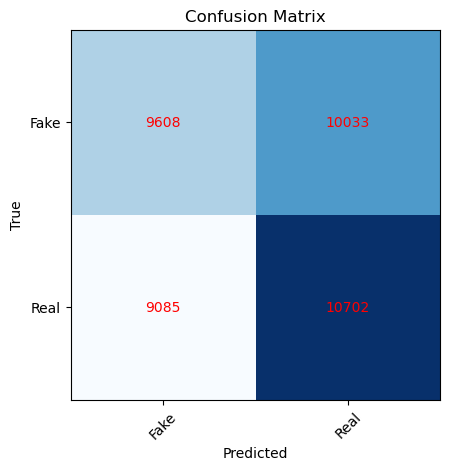

              precision    recall  f1-score   support

        Fake       0.51      0.49      0.50     19641
        Real       0.52      0.54      0.53     19787

    accuracy                           0.52     39428
   macro avg       0.52      0.52      0.51     39428
weighted avg       0.52      0.52      0.51     39428



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = out.argmax(1)
        y_true += y.cpu().tolist()
        y_pred += preds.cpu().tolist()

# Classes
classes = getattr(val_loader.dataset, "classes", [str(i) for i in set(y_true)])

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(y_true, y_pred, target_names=classes))


In [10]:
import torch.nn as nn

# Define the same criterion used in training
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, 100 * correct / total

# ✅ Show training and validation accuracy/loss
train_loss, train_acc = evaluate_model(model, train_loader, criterion, device)
val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.2f}%")
print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.2f}%")


Training Loss: 0.7069 | Training Accuracy: 47.92%
Validation Loss: 0.6939 | Validation Accuracy: 51.51%


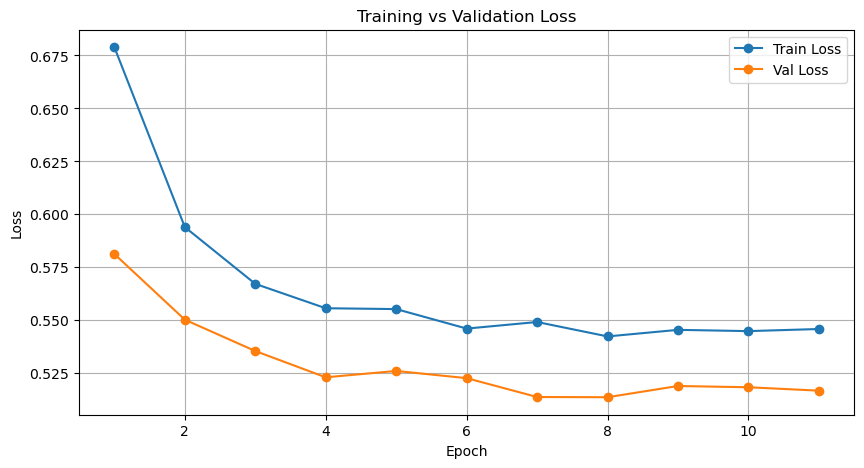

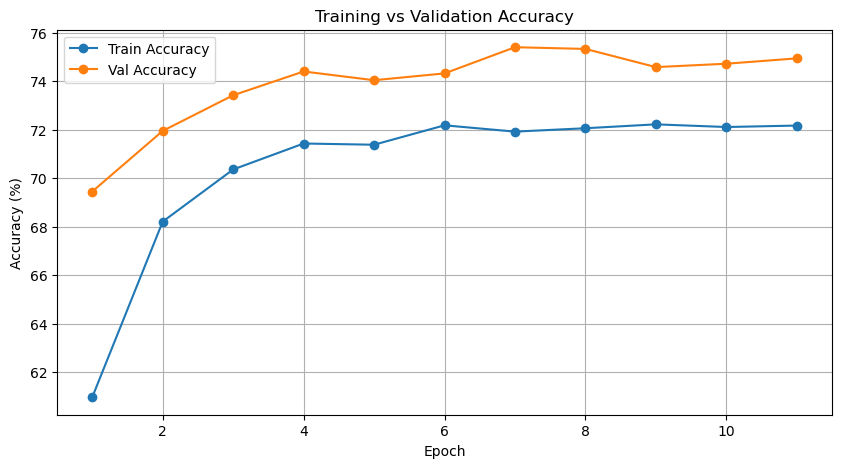

In [11]:
import matplotlib.pyplot as plt

# Values from your training log
train_losses = [0.6789, 0.5940, 0.5672, 0.5557, 0.5553, 0.5461, 0.5492, 0.5424, 0.5455, 0.5449, 0.5459]
val_losses   = [0.5813, 0.5503, 0.5355, 0.5231, 0.5261, 0.5227, 0.5138, 0.5137, 0.5190, 0.5184, 0.5168]
train_accs   = [60.97, 68.21, 70.36, 71.43, 71.38, 72.18, 71.92, 72.06, 72.22, 72.11, 72.17]
val_accs     = [69.45, 71.95, 73.42, 74.40, 74.04, 74.32, 75.40, 75.33, 74.58, 74.72, 74.94]

epochs = range(1, len(train_losses) + 1)

# ------------------------
# Loss Curve
# ------------------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------
# Accuracy Curve
# ------------------------
plt.figure(figsize=(10,5))
plt.plot(epochs, train_accs, marker='o', label="Train Accuracy")
plt.plot(epochs, val_accs, marker='o', label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
import os
from pathlib import Path
from typing import List, Tuple, Optional
import cv2
import numpy as np
from PIL import Image
import csv

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models

try:
    from facenet_pytorch import MTCNN
    _HAS_MTCNN = True
except Exception:
    _HAS_MTCNN = False
    MTCNN = None

# Config
IMG_SIZE = 224                       
MODEL_PATH = "resnet18_deepfake.pth" 
NUM_FRAMES_DEFAULT = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [51]:
def load_model(model_path: str = MODEL_PATH):
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 2)
    )

    if os.path.exists(model_path):
        state = torch.load(model_path, map_location=DEVICE)
        if isinstance(state, dict) and 'model' in state and not isinstance(state['model'], int):
            state = state['model']
        try:
            model.load_state_dict(state)
        except Exception:
            new_state = {}
            for k, v in state.items():
                new_key = k.replace('module.', '')
                new_state[new_key] = v
            model.load_state_dict(new_state)
        print(f"✅ Loaded weights from {model_path}")
    else:
        print(f"⚠️ WARNING: model path {model_path} not found — using random initialized weights.")

    model.to(DEVICE)
    model.eval()
    return model

model = load_model(MODEL_PATH)


✅ Loaded weights from resnet18_deepfake.pth


In [52]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


In [53]:
def extract_frames_from_video(video_path: str, num_frames: int = NUM_FRAMES_DEFAULT) -> List[np.ndarray]:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)
        cap.release()
        return frames

    indices = np.linspace(0, max(total - 1, 0), num_frames, dtype=np.int64)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frames.append(frame)
    cap.release()
    return frames


In [54]:
_face_cascade = None
_mtcnn = None

def _get_face_cascade():
    global _face_cascade
    if _face_cascade is None:
        cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        _face_cascade = cv2.CascadeClassifier(cascade_path)
    return _face_cascade

def _get_mtcnn():
    global _mtcnn
    if not _HAS_MTCNN:
        return None
    if _mtcnn is None:
        _mtcnn = MTCNN(keep_all=True, device=str(DEVICE))
    return _mtcnn

def detect_largest_face_and_crop(frame: np.ndarray, margin: float = 0.2, detector: str = 'haar') -> np.ndarray:
    h, w = frame.shape[:2]
    if detector == 'mtcnn' and _HAS_MTCNN:
        mt = _get_mtcnn()
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        boxes, probs = mt.detect(rgb)
        if boxes is None or len(boxes) == 0:
            return frame
        areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
        idx = int(np.argmax(areas))
        x1, y1, x2, y2 = boxes[idx].astype(int)
        dx = int((x2 - x1) * margin)
        dy = int((y2 - y1) * margin)
        x1 = max(0, x1 - dx); y1 = max(0, y1 - dy)
        x2 = min(w, x2 + dx); y2 = min(h, y2 + dy)
        return frame[y1:y2, x1:x2]

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    detector_c = _get_face_cascade()
    faces = detector_c.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    if len(faces) == 0:
        return frame
    x, y, fw, fh = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)[0]
    mx = int(fw * margin)
    my = int(fh * margin)
    x1 = max(0, x - mx); y1 = max(0, y - my)
    x2 = min(w, x + fw + mx); y2 = min(h, y + fh + my)
    return frame[y1:y2, x1:x2]


In [55]:
def preprocess_frame_for_model(frame: np.ndarray) -> torch.Tensor:
    img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    t = transform(img).unsqueeze(0).to(DEVICE)
    return t

def predict_single_frame_prob(frame: np.ndarray) -> float:
    if model is None:
        raise RuntimeError("Model not loaded. Check MODEL_PATH.")
    inp = preprocess_frame_for_model(frame)
    with torch.no_grad():
        out = model(inp)
        probs = F.softmax(out, dim=1).cpu().numpy()[0]
    return float(probs[1])  # मान लो class[1] = Real


In [56]:
import time

def predict_video(video_path: str, num_frames: int = 16, face_crop: bool = False, agg: str = 'mean'):
    t0 = time.time()

    # --- 1. Extract frames ---
    frames = extract_frames_from_video(video_path, num_frames=num_frames)
    print("Frame extraction time:", time.time() - t0); t1 = time.time()

    if len(frames) == 0:
        return "Unknown", 0.0, []

    # --- 2. Face crop (optional) ---
    if face_crop:
        frames = [detect_largest_face_and_crop(f) for f in frames]
    print("Face crop time:", time.time() - t1); t2 = time.time()

    # --- 3. Preprocess frames ---
    tensors = [preprocess_frame_for_model(f) for f in frames]
    batch = torch.cat(tensors, dim=0)
    print("Preprocessing time:", time.time() - t2); t3 = time.time()

    # --- 4. Model inference ---
    with torch.no_grad():
        out = model(batch.to(DEVICE))
        probs = F.softmax(out, dim=1).cpu().numpy()[:, 1]
    print("Model inference time:", time.time() - t3); t4 = time.time()

    # --- 5. Aggregation ---
    if agg == 'mean':
        score = float(np.mean(probs))
        label = "Real" if score >= 0.5 else "Fake"
    elif agg == 'majority':
        preds = [1 if p >= 0.5 else 0 for p in probs]
        s = sum(preds)
        score = float(s / max(1, len(preds)))
        label = "Real" if s > len(preds) / 2 else "Fake"
    else:
        raise ValueError("agg must be 'mean' or 'majority'")

    print("Aggregation + Total time:", time.time() - t4, " | TOTAL:", time.time() - t0)
    return label, score, probs.tolist()


In [57]:
def predict_image_file(image_path: str) -> Tuple[str, float]:
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Cannot read image {image_path}")
    prob = predict_single_frame_prob(img)
    label = "Real" if prob >= 0.5 else "Fake"
    return label, prob


In [59]:
def process_file(file_obj, face_crop_val, frames_to_sample, agg_val):
    if file_obj is None:
        return "No file provided.", []

    path = file_obj if isinstance(file_obj, str) else getattr(file_obj, 'name', None) or file_obj['name']
    print("📂 File received in Gradio:", path)   # Debug print

    ext = Path(path).suffix.lower()
    ...


In [60]:
def extract_frames_from_video(video_path: str, num_frames: int = 16):
    print("🎬 Opening video:", video_path)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print("❌ Could not open video.")
        return []

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print("📊 Total frames in video:", total)

    if total <= 0:
        cap.release()
        return []

    indices = np.linspace(0, max(total - 1, 0), num_frames, dtype=np.int64)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if ret and frame is not None:
            frames.append(frame)

    cap.release()
    print("✅ Extracted frames:", len(frames))
    return frames


In [61]:
import gradio as gr

def build_gradio_app():
    with gr.Blocks() as demo:
        gr.Markdown("# Deepfake checker — drop an image or a video")

        with gr.Row():
            file_in = gr.File(label="Drop image (.jpg/.png) or video (.mp4/.avi)")
            opts = gr.Column()
            with opts:
                face_crop = gr.Checkbox(label="Crop largest face", value=False)
                num_frames = gr.Slider(minimum=4, maximum=128, step=1, value=NUM_FRAMES_DEFAULT, label="Frames")
                agg_method = gr.Radio(choices=['mean', 'majority'], value='mean', label="Aggregation")

        out_text = gr.Textbox(label="Result", interactive=False)
        out_gallery = gr.Gallery(label="Sample frames")   # 👈 style() हटा दिया

        def process_file(file_obj, face_crop_val, frames_to_sample, agg_val):
            if file_obj is None:
                return "No file provided.", []
            path = file_obj if isinstance(file_obj, str) else getattr(file_obj, 'name', None) or file_obj['name']
            ext = Path(path).suffix.lower()
            if ext in ['.jpg', '.jpeg', '.png']:
                lbl, p = predict_image_file(path)
                return f"{lbl} (score={p:.3f})", []
            else:
                lbl, score, probs = predict_video(path, num_frames=frames_to_sample, face_crop=face_crop_val, agg=agg_val)
                frames = extract_frames_from_video(path, num_frames=min(8, frames_to_sample))
                if face_crop_val:
                    frames = [detect_largest_face_and_crop(f) for f in frames]
                pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)).resize((224,224)) for f in frames]
                return f"{lbl} (score={score:.3f})", pil_frames

        btn = gr.Button("Check")
        btn.click(process_file, inputs=[file_in, face_crop, num_frames, agg_method], outputs=[out_text, out_gallery])

    return demo

app = build_gradio_app()
app.launch()


* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.
